# 01 — Exploratory Data Analysis: Weekly Unit Demand

## Purpose
Load the Power BI semantic model export, diagnose data quality, characterize the
panel structure (store x division x week), and produce a clean weekly unit demand
table for the forecasting pipeline.

## Scope
- **Stores**: ~32 Club Piscine locations across Quebec + 1 in Ontario (Nepean)
- **Products**: 34 division codes (internal ERP identifiers — see action items below)
- **Time span**: Nov 2023 - Mar 2026 (~124 weeks, covering ~2 complete fiscal years)
- **Granularity**: Weekly, by store and division

## Data Source
Export from **V2_STATISTIQUES** semantic model (Power BI), sliced per store.

| Column | Role |
|--------|------|
| `Date de Vente` | Transaction date |
| `No. magasin` | Store code (e.g., "CP01 - Quebec") |
| `Division Code corrigee` | Product division code |
| `Quantite facturee` | **Target variable** — units sold |

## Key Assumptions
1. **Fiscal year**: Nov 1 - Oct 31 (FY2024 = Nov 2023 - Oct 2024). All year references use fiscal year.
2. **Returns**: Negative quantities represent returns. They are netted at the weekly level, and net units are clipped to 0 (a week cannot have negative demand).
3. **Zero-demand weeks**: If a store x division has no transactions in a week, that week is absent from the output (not zero-filled). Downstream models must decide how to handle implicit zeros.

## Output
- `data/processed/weekly_units.csv` — weekly unit demand by store x division
- `data/processed/store_region_map.csv` — store metadata (city, province)

---
## Cell 1 — Imports & Setup
---

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_palette('husl')

PROJECT_ROOT   = Path('..')
DATA_RAW       = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# Power BI adds these junk rows to every export — removing them
PBI_JUNK = [
    'Total',
    'No filters applied',
    'Exported data exceeded the allowed volume. Some data may have been omitted.'
]

# ── Load Table Calendrier (client's official fiscal calendar) ─────────────────
cal = pd.read_excel(DATA_RAW / 'Table Calendrier.xlsx', usecols=[
    'Date', 'FiscalYear', 'FiscalMonthNum', 'FiscalQuarter',
    '_Semaine fiscale NEW', 'Fin de semaine'
])
cal['Date'] = pd.to_datetime(cal['Date'])
cal = cal.rename(columns={
    'FiscalYear': 'fiscal_year_label',
    'FiscalMonthNum': 'fiscal_month',
    'FiscalQuarter': 'fiscal_quarter',
    '_Semaine fiscale NEW': 'fiscal_week',
    'Fin de semaine': 'cal_week_ending',
})
# Extract numeric fiscal year from label like "2024 (fiscale)"
cal['fiscal_year'] = cal['fiscal_year_label'].str.extract(r'(\d{4})').astype(int)
cal['cal_week_ending'] = pd.to_datetime(cal['cal_week_ending'])

print(f'Table Calendrier loaded: {len(cal):,} days')
print(f'Date range: {cal["Date"].min().date()} -> {cal["Date"].max().date()}')
print(f'Fiscal years: {sorted(cal["fiscal_year"].unique())}')
print(f'Fiscal weeks per FY:')
print(cal.groupby('fiscal_year')['fiscal_week'].max().to_string())

# Fiscal month order for charts (Nov=1st month of FY, Oct=12th)
FISCAL_MONTH_ORDER = [11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
FISCAL_MONTH_LABELS = ['Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct']

print('\nSetup complete')

Table Calendrier loaded: 1,096 days
Date range: 2023-11-01 -> 2026-10-31
Fiscal years: [np.int64(2024), np.int64(2025), np.int64(2026)]
Fiscal weeks per FY:
fiscal_year
2024    53
2025    52
2026    52

Setup complete


---
## Cell 2 — Load Sliced Exports (raw/slices CSV for each store)

---

In [21]:
SLICES_DIR = DATA_RAW / 'slices'
files = sorted([f for f in SLICES_DIR.glob('*.xlsx') if not f.name.startswith('~$')])
files += sorted([f for f in SLICES_DIR.glob('*.csv') if not f.name.startswith('~$')])
print(f'Found {len(files)} slice files (excluding lock files)')

slices = []
for i, f in enumerate(files):
    print(f'  Loading {f.name}... ({i+1}/{len(files)})', end='\r')
    s = pd.read_excel(f) if f.suffix == '.xlsx' else pd.read_csv(f)
    s = s[~s['Magasins'].isin(PBI_JUNK)].copy()
    slices.append(s)

print(f'  Loaded {len(files)} files.{" " * 30}')

raw = pd.concat(slices, ignore_index=True).drop_duplicates()
raw['Date de Vente']          = pd.to_datetime(raw['Date de Vente'], errors='coerce')
raw['Quantité facturée']      = pd.to_numeric(raw['Quantité facturée'], errors='coerce')
raw['No. magasin']            = raw['Magasins'].astype(str).str.strip()
raw['Division Code corrigée'] = raw['Division Code corrigée'].astype(str).str.strip()
raw = raw.dropna(subset=['Date de Vente', 'Quantité facturée'])

# ── Merge fiscal year from Table Calendrier (client's official calendar) ──────
raw = raw.merge(
    cal[['Date','fiscal_year','fiscal_month','fiscal_quarter','fiscal_week']],
    left_on='Date de Vente', right_on='Date', how='left'
).drop(columns=['Date'])

# Check for unmatched dates (outside calendar range)
unmatched = raw['fiscal_year'].isna().sum()
if unmatched > 0:
    print(f'WARNING: {unmatched} rows have dates outside Table Calendrier range')
    print(f'  Dates outside range: {raw.loc[raw["fiscal_year"].isna(), "Date de Vente"].min().date()} '
          f'to {raw.loc[raw["fiscal_year"].isna(), "Date de Vente"].max().date()}')
raw['fiscal_year'] = raw['fiscal_year'].astype('Int64')

print(f'\nCombined rows : {len(raw):,} from {len(files)} files')
print(f'Date range    : {raw["Date de Vente"].min().date()} -> {raw["Date de Vente"].max().date()}')
print(f'\nFiscal year breakdown (from Table Calendrier):')
fy_summary = (
    raw.groupby('fiscal_year')
       .agg(start=('Date de Vente','min'), end=('Date de Vente','max'),
            rows=('Quantité facturée','count'), total_units=('Quantité facturée','sum'))
)
fy_summary['start'] = fy_summary['start'].dt.date
fy_summary['end']   = fy_summary['end'].dt.date
print(fy_summary.to_string())

Found 32 slice files (excluding lock files)
  Loaded 32 files.                              

Combined rows : 204,236 from 32 files
Date range    : 2023-11-02 -> 2026-03-10

Fiscal year breakdown (from Table Calendrier):
                  start         end    rows  total_units
fiscal_year                                             
2024         2023-11-02  2024-10-31   78780   2812587.04
2025         2024-11-01  2025-10-31  108948   6925436.85
2026         2025-11-01  2026-03-10   16508   1128888.71


---
## Clean & Filter

### Store exclusion logic
1. **Automatic**: Remove test stores (< 10 weeks of data), rows with 'nan' store names, and liquidation stores (detected by name)
2. **Data-driven**: Investigate any other stores flagged for quality issues using metrics before excluding
---

In [ ]:
# ── Step 1: Remove obvious junk rows ──────────────────────────────────────────
raw = raw[raw['No. magasin'] != 'nan'].copy()
raw = raw[raw['Division Code corrigée'] != 'nan'].copy()

# ── Step 2: Detect liquidation stores by name pattern ─────────────────────────
all_stores = raw['No. magasin'].unique()
liquidation_stores = [s for s in all_stores if 'liquidation' in s.lower()]
print(f"Liquidation stores detected: {liquidation_stores}")

# ── Step 3: Detect test/placeholder stores by data volume ─────────────────────
raw['week_ending_tmp'] = raw['Date de Vente'] + pd.offsets.Week(weekday=6)
store_diagnostics = (
    raw.groupby('No. magasin')
       .agg(
           n_weeks       = ('week_ending_tmp', 'nunique'),
           n_rows        = ('Quantité facturée', 'count'),
           total_units   = ('Quantité facturée', 'sum'),
           median_weekly  = ('Quantité facturée', 'median'),
           n_divisions   = ('Division Code corrigée', 'nunique'),
           first_date    = ('Date de Vente', 'min'),
           last_date     = ('Date de Vente', 'max'),
       )
       .sort_values('n_weeks', ascending=True)
)
store_diagnostics['first_date'] = store_diagnostics['first_date'].dt.date
store_diagnostics['last_date']  = store_diagnostics['last_date'].dt.date

test_stores = store_diagnostics[store_diagnostics['n_weeks'] < 10].index.tolist()
print(f"Test/placeholder stores (< 10 weeks): {test_stores}")

# ── Step 4: Show diagnostic table for ALL stores ─────────────────────────────
print(f"\n=== Store Diagnostic Table (sorted by weeks ascending) ===")
print(store_diagnostics.to_string())

# ── Step 5: Apply exclusions ─────────────────────────────────────────────────
EXCLUDE_STORES = list(set(liquidation_stores + test_stores))
raw = raw[~raw['No. magasin'].isin(EXCLUDE_STORES)].copy()
raw = raw.drop(columns=['week_ending_tmp'])

print(f"\n=== Exclusion Summary ===")
for s in sorted(EXCLUDE_STORES):
    if s in liquidation_stores:
        reason = "Liquidation store (closing/closed)"
    else:
        reason = f"Insufficient data (< 10 weeks)"
    print(f"  {s}: {reason}")

# ── NOTE on stores with unusual patterns ──────────────────────────────────────
# CP20 - Valleyfield: Part of franchise group CP11 (Vaudreuil-Dorion). May have
#   fewer weeks or lower volume if it's a smaller satellite location, or if POS
#   data exports started later. Previously excluded without justification — now
#   included so the diagnostic table shows the evidence. If coverage is low,
#   downstream models will handle it via the sparsity tier (see Panel Structure).
#
# CP40 - Thetford Mines: Standalone franchise (Accomba POS). Same situation —
#   previously excluded with no documented reason. The diagnostic table above
#   shows exactly how many weeks/divisions/units it has vs other stores. If the
#   data looks sparse, it may be a genuinely smaller market (pop. ~26K) or a
#   newer data connection.
#
# CP05 - Sherbrooke: Also previously excluded. Franchise "Tourbillon Provincial
#   Spas Ltée" (Accomba POS). Check n_weeks and n_divisions above.

print(f'\nAfter cleaning : {len(raw):,} rows')
print(f'Stores         : {raw["No. magasin"].nunique()}')
print(f'Divisions ({raw["Division Code corrigée"].nunique()}): {sorted(raw["Division Code corrigée"].unique())}')
print(f'Negative units : {int((raw["Quantité facturée"] < 0).sum()):,}  (returns — kept, clipped at weekly level)')

---
## Store Mapping (from Table_Magasins)

Using the client's official store master table for city, franchise group, and POS system.
This replaces manual name parsing.
---

In [ ]:
# ── Load Table_Magasins (client's official store master) ──────────────────────
store_master = pd.read_excel(DATA_RAW / 'Table_Magasins.xlsx')

# Filter to retail stores only (exclude warehouses, HQ, demo stores)
store_master = store_master[
    ~store_master['Magasins'].str.contains('Entrepôt|Siège social|Démo', case=False, na=False)
].copy()

print(f"Table_Magasins: {len(store_master)} retail stores (excluding warehouses, HQ, demo)")
print(f"\nStore master columns: {list(store_master.columns)}")

# Merge onto raw data
raw = raw.merge(
    store_master[['Magasins', 'Ville magasins', 'Regroupement', 'Nom Regroupement', 'Système informatique']],
    left_on='No. magasin', right_on='Magasins', how='left'
).drop(columns=['Magasins'])

raw = raw.rename(columns={
    'Ville magasins': 'city',
    'Regroupement': 'franchise_group',
    'Nom Regroupement': 'franchise_name',
    'Système informatique': 'pos_system',
})

# Province: ON for Nepean, QC for everything else
raw['province'] = np.where(raw['No. magasin'].str.startswith('CP202'), 'ON', 'QC')

# Check for unmatched stores
unmatched = raw[raw['city'].isna()]['No. magasin'].unique()
if len(unmatched) > 0:
    print(f"\nWARNING: {len(unmatched)} stores not found in Table_Magasins: {unmatched}")

# ── Save store region map ─────────────────────────────────────────────────────
store_map = (
    raw[['No. magasin','city','province','franchise_group','franchise_name','pos_system']]
    .drop_duplicates()
    .rename(columns={'No. magasin':'store_code'})
    .sort_values('store_code').reset_index(drop=True)
)
store_map.to_csv(DATA_PROCESSED / 'store_region_map.csv', index=False)
print(f"\n{store_map.to_string(index=False)}")
print(f'\nSaved: store_region_map.csv')

# ── Which stores from Table_Magasins are MISSING from our data? ──────────────
all_master_stores = set(store_master['Magasins'].str.strip())
all_data_stores = set(raw['No. magasin'].unique())
missing_stores = all_master_stores - all_data_stores
if missing_stores:
    print(f"\nStores in Table_Magasins but NOT in slice data ({len(missing_stores)}):")
    for s in sorted(missing_stores):
        city = store_master.loc[store_master['Magasins'].str.strip() == s, 'Ville magasins'].values
        city = city[0] if len(city) > 0 else '?'
        print(f"  {s} ({city})")

---
## Cell 5 — Division Breakdown
---

Division Code corrigée  total_units  transactions  avg_units_per_tx  pct_units
                    AP   4584249.62         18704        245.094612       41.8
                    PC   2473956.50         20801        118.934498       22.6
                    PI    777623.45         17444         44.578276        7.1
                    DI    673974.47          2988        225.560398        6.1
                    SE    640771.71         10615         60.364740        5.8
                    AZ    453931.98          5572         81.466615        4.1
                    AS    329431.80         17734         18.576283        3.0
                    IN    313690.75          9057         34.635172        2.9
                    ME    216830.50         14048         15.434973        2.0
                    LO    192812.00         13978         13.793962        1.8
                    LI     64278.50          9619          6.682451        0.6
                   INM     38628.50          2769   

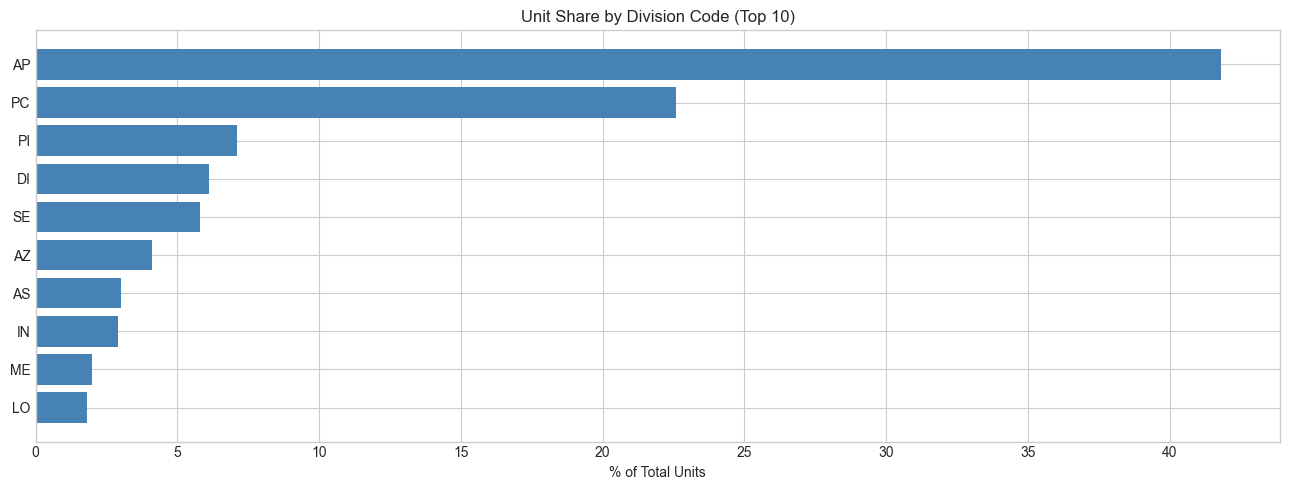

✅ Saved: division_units_breakdown.png


In [24]:
div_summary = (
    raw.groupby('Division Code corrigée')
       .agg(total_units=('Quantité facturée','sum'),
            transactions=('Quantité facturée','count'),
            avg_units_per_tx=('Quantité facturée','mean'))
       .sort_values('total_units', ascending=False).reset_index()
)
div_summary['pct_units'] = (div_summary['total_units'] / div_summary['total_units'].sum() * 100).round(1)
print(div_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
top10 = div_summary.head(10)
ax.barh(top10['Division Code corrigée'][::-1], top10['pct_units'][::-1], color='steelblue')
ax.set_xlabel('% of Total Units')
ax.set_title('Unit Share by Division Code (Top 10)')
plt.tight_layout()
plt.savefig(FIGURES / 'division_units_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: division_units_breakdown.png')

---
## Cell 6 — History & Coverage Check
---

In [25]:
raw['week_ending'] = raw['Date de Vente'] + pd.offsets.Week(weekday=6)

total_weeks = raw['week_ending'].nunique()
print(f'Date range    : {raw["Date de Vente"].min().date()} -> {raw["Date de Vente"].max().date()}')
print(f'Total weeks   : {total_weeks}')

# Coverage by fiscal year (from Table Calendrier)
fy_weeks = raw.groupby('fiscal_year')['week_ending'].nunique()
for fy, nw in fy_weeks.items():
    status = 'complete' if nw >= 50 else 'partial'
    print(f'  FY{fy}: {nw} weeks ({status})')

n_complete_fy = (fy_weeks >= 50).sum()
print(f'\nComplete fiscal years: {n_complete_fy} (need >= 2 for annual seasonality)')

g = raw.groupby(['No. magasin','Division Code corrigée'])['week_ending'].nunique().reset_index(name='n_weeks')
print(f'\nTotal Store x Division groups : {len(g)}')
print(f'Groups >= 52 weeks (full year) : {int((g.n_weeks >= 52).sum())}')
print(f'Groups >= 26 weeks (half year) : {int((g.n_weeks >= 26).sum())}')
print(f'Groups <  10 weeks (sparse)    : {int((g.n_weeks < 10).sum())}')

Date range    : 2023-11-02 -> 2026-03-10
Total weeks   : 124
  FY2024: 53 weeks (complete)
  FY2025: 53 weeks (complete)
  FY2026: 20 weeks (partial)

Complete fiscal years: 2 (need >= 2 for annual seasonality)

Total Store x Division groups : 777
Groups >= 52 weeks (full year) : 508
Groups >= 26 weeks (half year) : 623
Groups <  10 weeks (sparse)    : 91


---
## Cell 7 — Unit Demand Visualizations
---

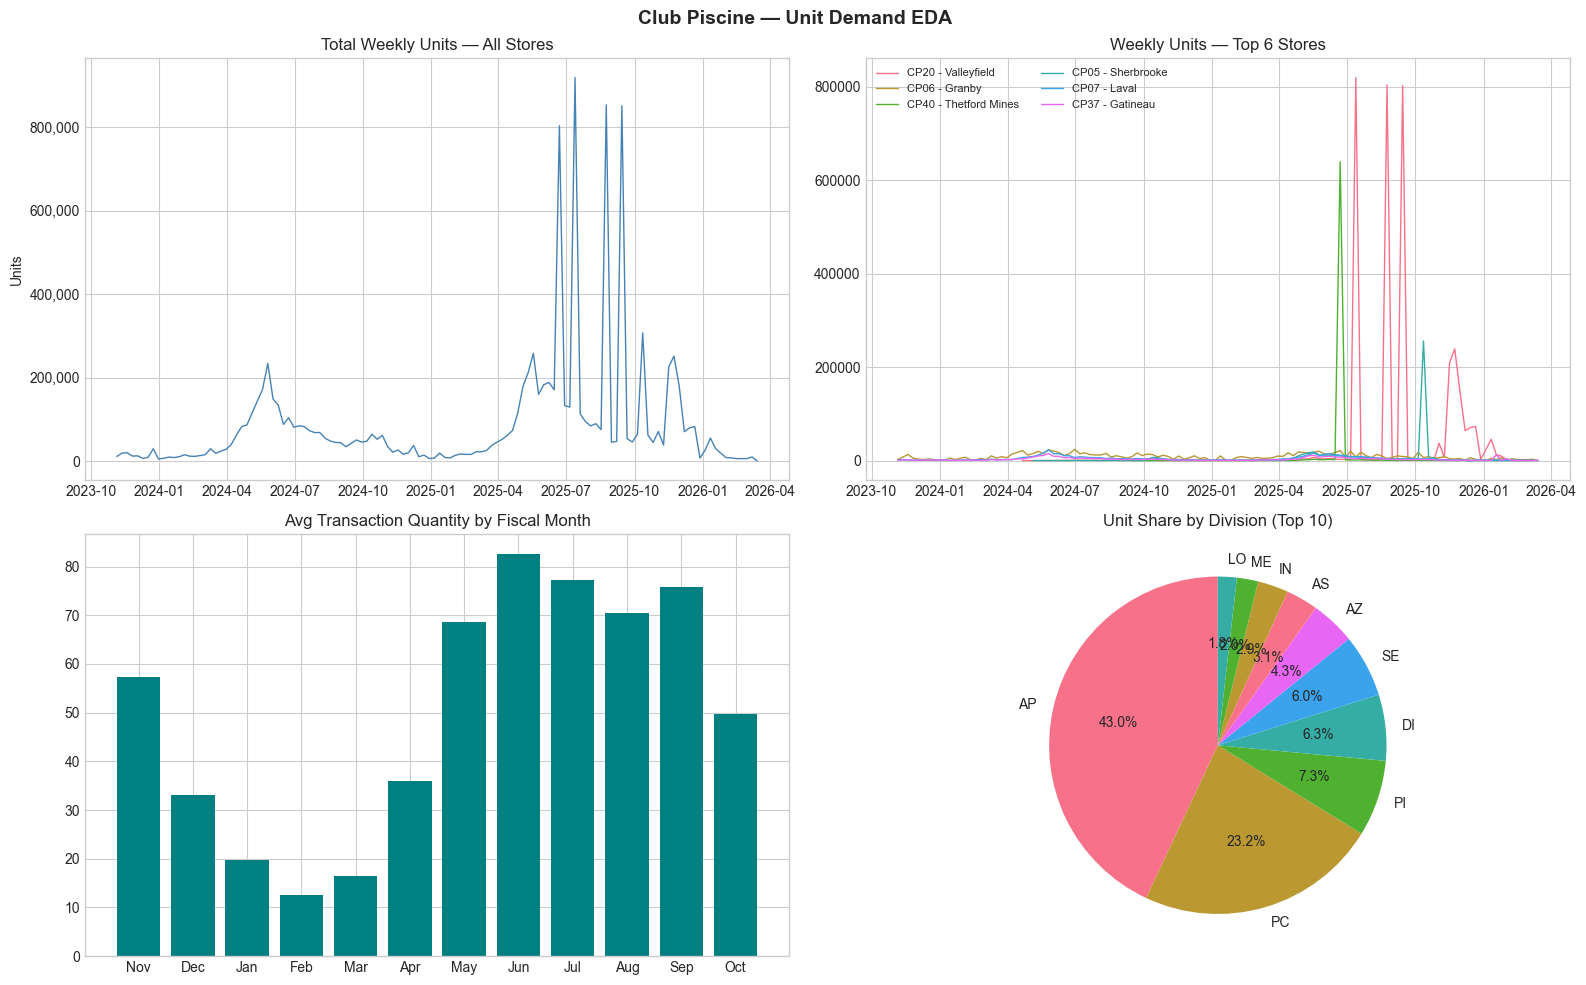

Saved: units_eda_overview.png


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Weekly units — all stores
weekly_total = raw.groupby('week_ending')['Quantité facturée'].sum()
axes[0,0].plot(weekly_total.index, weekly_total.values, color='steelblue', linewidth=1)
axes[0,0].set_title('Total Weekly Units — All Stores')
axes[0,0].set_ylabel('Units')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))

# Weekly units — top 6 stores
top_stores = raw.groupby('No. magasin')['Quantité facturée'].sum().nlargest(6).index
for s in top_stores:
    d = raw[raw['No. magasin']==s].groupby('week_ending')['Quantité facturée'].sum()
    axes[0,1].plot(d.index, d.values, label=s, linewidth=1)
axes[0,1].set_title('Weekly Units — Top 6 Stores')
axes[0,1].legend(fontsize=8, ncol=2)

# Monthly seasonality — FISCAL MONTH ORDER (Nov → Oct)
raw['month'] = raw['Date de Vente'].dt.month
month_avg = raw.groupby('month')['Quantité facturée'].mean()
# Reorder to fiscal year: Nov, Dec, Jan, ..., Oct
fiscal_month_avg = month_avg.reindex(FISCAL_MONTH_ORDER)
axes[1,0].bar(range(len(FISCAL_MONTH_ORDER)), fiscal_month_avg.values, color='teal')
axes[1,0].set_title('Avg Transaction Quantity by Fiscal Month')
axes[1,0].set_xticks(range(len(FISCAL_MONTH_LABELS)))
axes[1,0].set_xticklabels(FISCAL_MONTH_LABELS)

# Unit share by division
div_units = raw.groupby('Division Code corrigée')['Quantité facturée'].sum().nlargest(10)
axes[1,1].pie(div_units.values, labels=div_units.index, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Unit Share by Division (Top 10)')

plt.suptitle('Club Piscine — Unit Demand EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'units_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: units_eda_overview.png')

---
## Cell 8 — Weekly Aggregation (Target Variable)

Aggregate to **Week × Store × Division** — one row per group per week.
- `units` = **net units sold** (sum of Quantité facturée, clipped at 0 at weekly level)
- `gross_units` = units sold before returns
- `returns` = units returned
---

In [ ]:
weekly = (
    raw.groupby(['week_ending','No. magasin','city','province','Division Code corrigée'])
       .agg(
           units          = ('Quantité facturée', 'sum'),
           gross_units    = ('Quantité facturée', lambda x: x[x > 0].sum()),
           returns        = ('Quantité facturée', lambda x: abs(x[x < 0].sum())),
           n_transactions = ('Quantité facturée', 'count'),
           fiscal_year    = ('fiscal_year', 'first'),
           fiscal_week    = ('fiscal_week', 'first'),
       )
       .reset_index()
       .rename(columns={'No. magasin':'store_code', 'Division Code corrigée':'division_code'})
)

# Clip net units at 0 — a week can't have negative demand for ordering
weekly['units'] = weekly['units'].clip(lower=0)

print(f'Weekly rows  : {len(weekly):,}')
print(f'Date range   : {weekly["week_ending"].min().date()} -> {weekly["week_ending"].max().date()}')
print(f'Unique weeks : {weekly["week_ending"].nunique()}')
print(f'Stores       : {weekly["store_code"].nunique()}')
print(f'Divisions    : {weekly["division_code"].nunique()}')
print(f'Groups       : {weekly.groupby(["store_code","division_code"]).ngroups}')
print(f'Fiscal years : {sorted(weekly["fiscal_year"].dropna().unique())}')

weekly.to_csv(DATA_PROCESSED / 'weekly_units.csv', index=False)
print(f'\nSaved: weekly_units.csv')
print('Next -> 02_weather_integration.ipynb')

---
## Missing Value Analysis
---

In [28]:
print("=== Missing Value Analysis ===\n")
print("Nulls per column in raw data:")
null_counts = raw.isnull().sum()
null_pcts = (null_counts / len(raw) * 100).round(2)
null_df = pd.DataFrame({'nulls': null_counts, 'pct': null_pcts})
print(null_df[null_df['nulls'] > 0].to_string() if null_df['nulls'].sum() > 0 else "  No nulls found in cleaned data")

print(f"\nZero-quantity rows: {(raw['Quantité facturée'] == 0).sum():,}")
print(f"Negative quantity rows (returns): {(raw['Quantité facturée'] < 0).sum():,}")
print(f"Positive quantity rows: {(raw['Quantité facturée'] > 0).sum():,}")

=== Missing Value Analysis ===

Nulls per column in raw data:
  No nulls found in cleaned data

Zero-quantity rows: 3,040
Negative quantity rows (returns): 2,644
Positive quantity rows: 197,650


---
## Store Coverage Analysis

Club Piscine operates ~42 stores across Quebec. This section documents which stores
are present in the data and which are missing. Coverage is expected to improve
when the Power BI semantic model API connection is established.

---

Stores in data: 32
Stores excluded: []

Active stores in dataset:


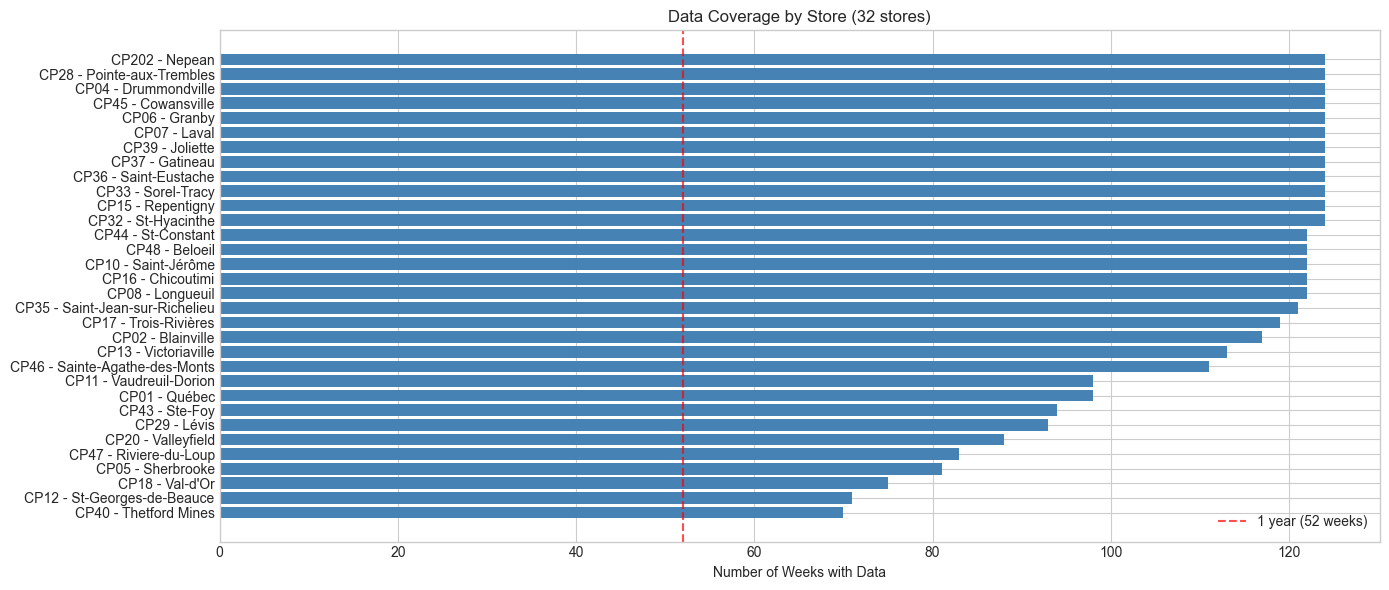


Stores with < 52 weeks: 0
Stores with >= 52 weeks: 32


In [29]:
print(f"Stores in data: {raw['No. magasin'].nunique()}")
print(f"Stores excluded: {EXCLUDE_STORES}")
print(f"\nActive stores in dataset:")

store_weeks = (
    raw.groupby('No. magasin')['week_ending']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name='n_weeks')
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(store_weeks['No. magasin'][::-1], store_weeks['n_weeks'][::-1], color='steelblue')
ax.set_xlabel('Number of Weeks with Data')
ax.set_title(f'Data Coverage by Store ({raw["No. magasin"].nunique()} stores)')
ax.axvline(x=52, color='red', linestyle='--', alpha=0.7, label='1 year (52 weeks)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'store_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nStores with < 52 weeks: {(store_weeks['n_weeks'] < 52).sum()}")
print(f"Stores with >= 52 weeks: {(store_weeks['n_weeks'] >= 52).sum()}")

---
## Target Variable Distribution
---

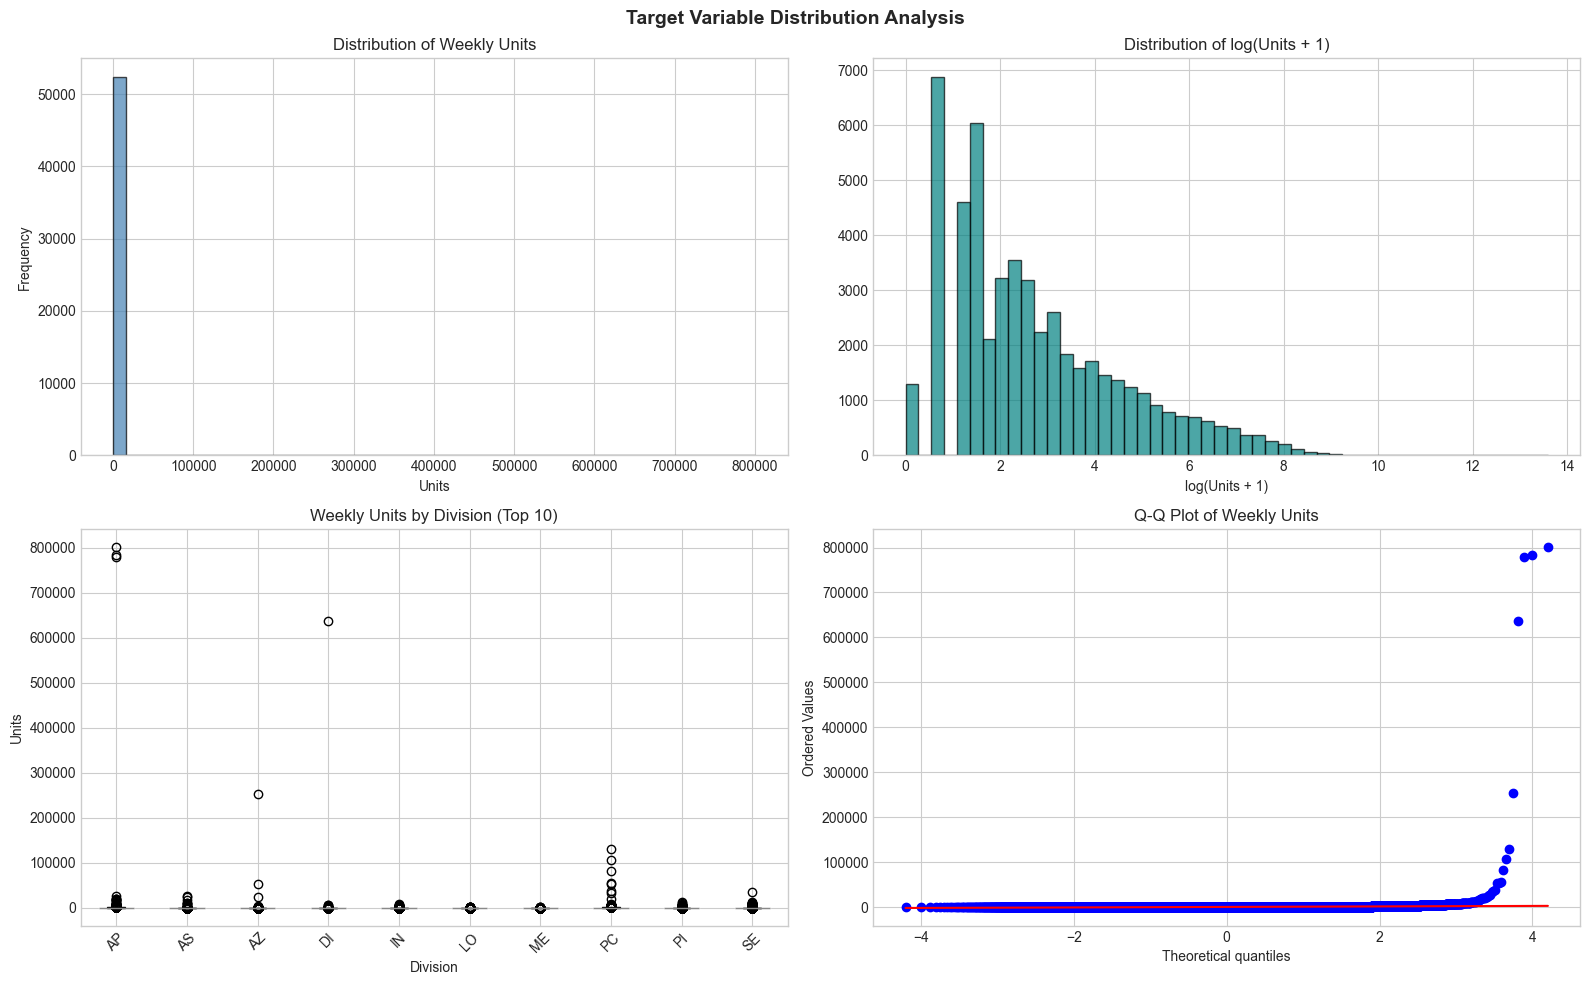

Skewness:  107.564
Kurtosis:  12055.204
Log skew:  0.921
Log kurt:  0.356

Zero-unit weeks: 1,290 (2.5%)


In [30]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Weekly units distribution
axes[0,0].hist(weekly['units'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].set_title('Distribution of Weekly Units')
axes[0,0].set_xlabel('Units'); axes[0,0].set_ylabel('Frequency')

# Log-transformed distribution
log_units = np.log1p(weekly['units'])
axes[0,1].hist(log_units, bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0,1].set_title('Distribution of log(Units + 1)')
axes[0,1].set_xlabel('log(Units + 1)')

# Box plots by top 10 divisions
top10_divs = weekly.groupby('division_code')['units'].sum().nlargest(10).index
box_data = weekly[weekly['division_code'].isin(top10_divs)]
box_data.boxplot(column='units', by='division_code', ax=axes[1,0], rot=45)
axes[1,0].set_title('Weekly Units by Division (Top 10)')
axes[1,0].set_xlabel('Division'); axes[1,0].set_ylabel('Units')
axes[1,0].get_figure().suptitle('')

# QQ plot
scipy_stats.probplot(weekly['units'].dropna(), dist='norm', plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot of Weekly Units')

plt.suptitle('Target Variable Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Skewness:  {weekly['units'].skew():.3f}")
print(f"Kurtosis:  {weekly['units'].kurtosis():.3f}")
print(f"Log skew:  {log_units.skew():.3f}")
print(f"Log kurt:  {log_units.kurtosis():.3f}")
print(f"\nZero-unit weeks: {(weekly['units'] == 0).sum():,} ({(weekly['units'] == 0).mean()*100:.1f}%)")

---
## Outlier Detection (IQR Method)

Outliers are flagged but NOT removed \u2014 they may represent genuine demand spikes
(e.g., promotions, seasonal surges).

---

IQR outliers: 3,103 of 52,336 rows (5.9%)


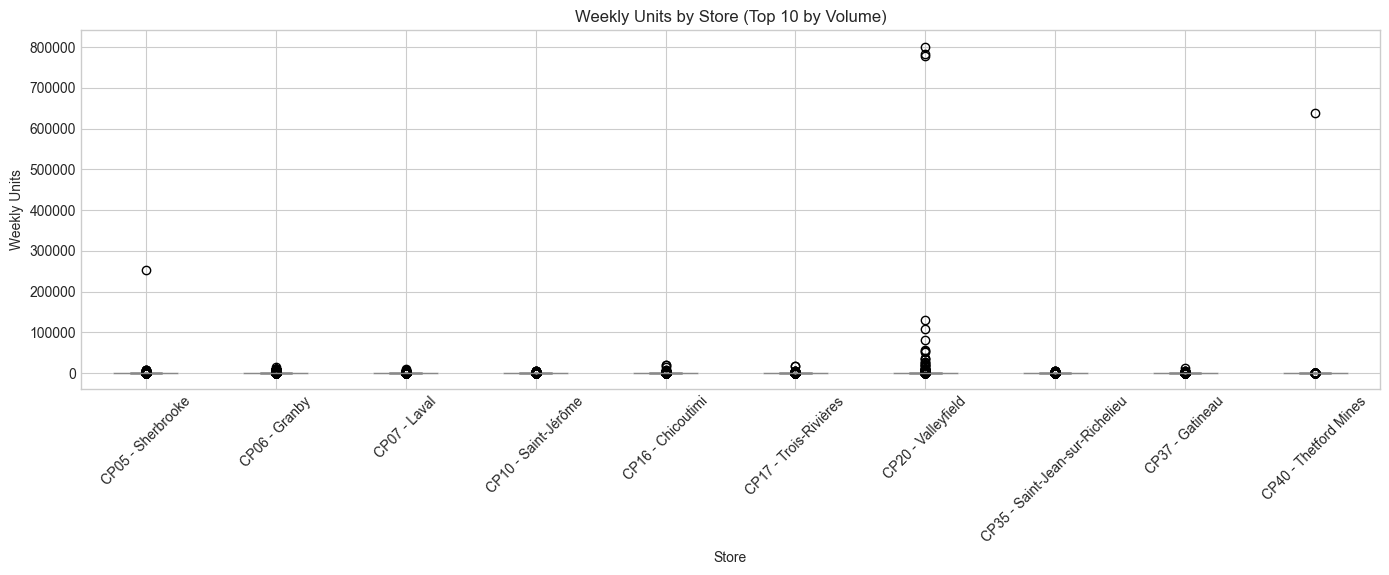

In [31]:
def flag_iqr_outliers(group):
    q1 = group['units'].quantile(0.25)
    q3 = group['units'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    group['is_outlier'] = ((group['units'] < lower) | (group['units'] > upper)).astype(int)
    return group

weekly_flagged = weekly.groupby(['store_code', 'division_code'], group_keys=False).apply(flag_iqr_outliers)
n_outliers = weekly_flagged['is_outlier'].sum()
print(f"IQR outliers: {n_outliers:,} of {len(weekly_flagged):,} rows ({n_outliers/len(weekly_flagged)*100:.1f}%)")

# Box plots by top 10 stores
top10_stores = weekly.groupby('store_code')['units'].sum().nlargest(10).index
fig, ax = plt.subplots(figsize=(14, 6))
store_data = weekly[weekly['store_code'].isin(top10_stores)]
store_data.boxplot(column='units', by='store_code', ax=ax, rot=45)
ax.set_title('Weekly Units by Store (Top 10 by Volume)')
ax.set_xlabel('Store'); ax.set_ylabel('Weekly Units')
ax.get_figure().suptitle('')
plt.tight_layout()
plt.savefig(FIGURES / 'outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Statistical Tests (Time Series Properties)

Testing stationarity, autocorrelation, and seasonal decomposition
on the aggregate weekly demand series.

---

=== Augmented Dickey-Fuller Test ===
  Test statistic: -2.0334
  p-value:        0.2721
  Lags used:      11
  Conclusion:     Non-stationary (α=0.05)

=== KPSS Test (trend) ===
  Test statistic: 0.1810
  p-value:        0.0231
  Conclusion:     Non-stationary (α=0.05)


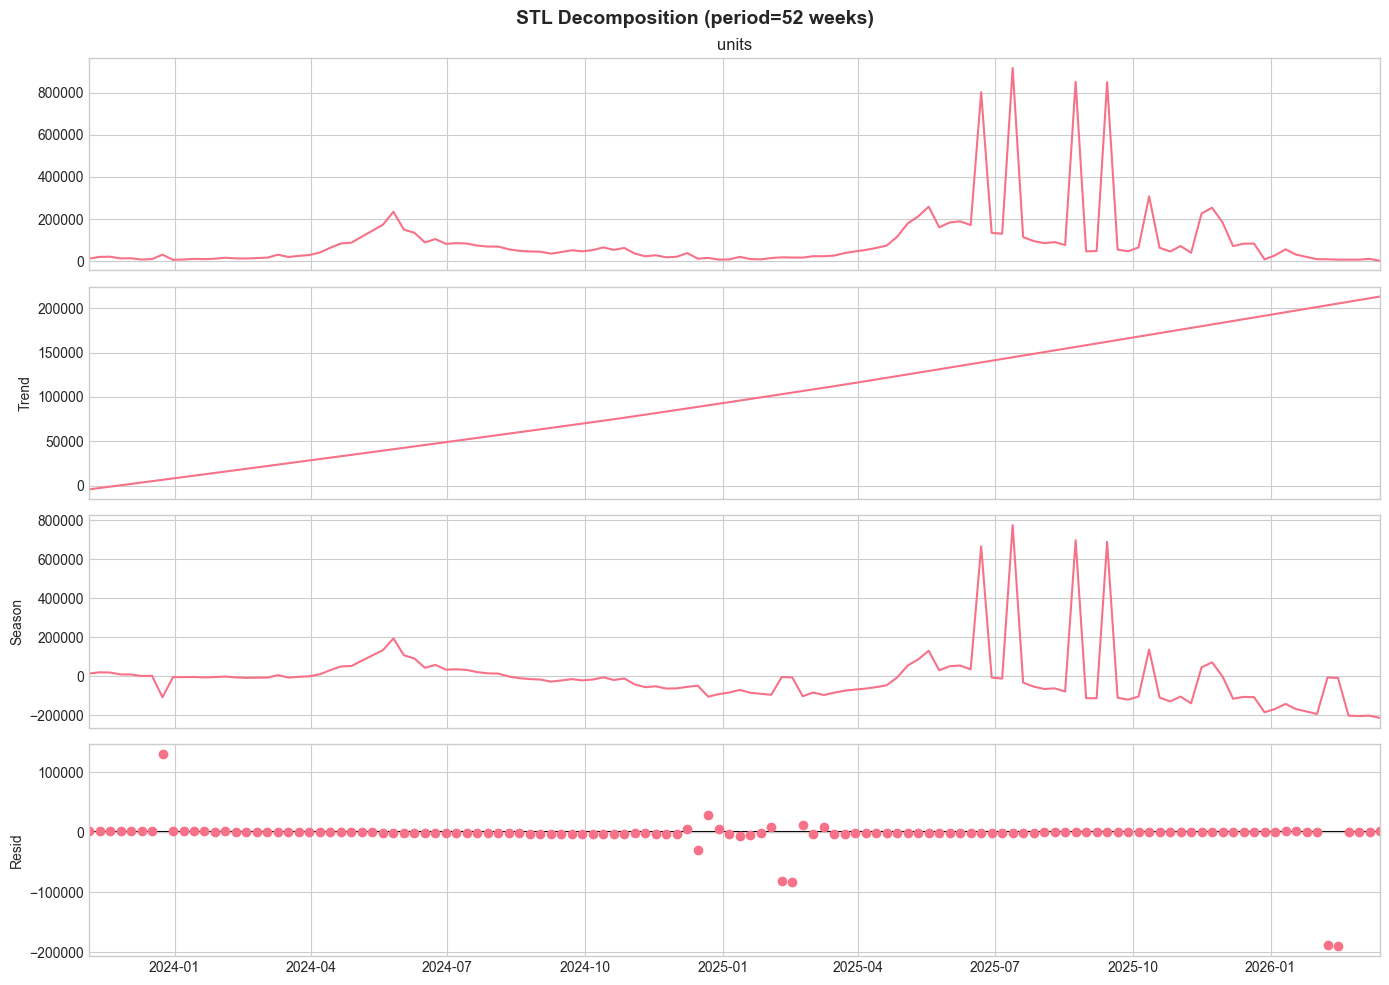

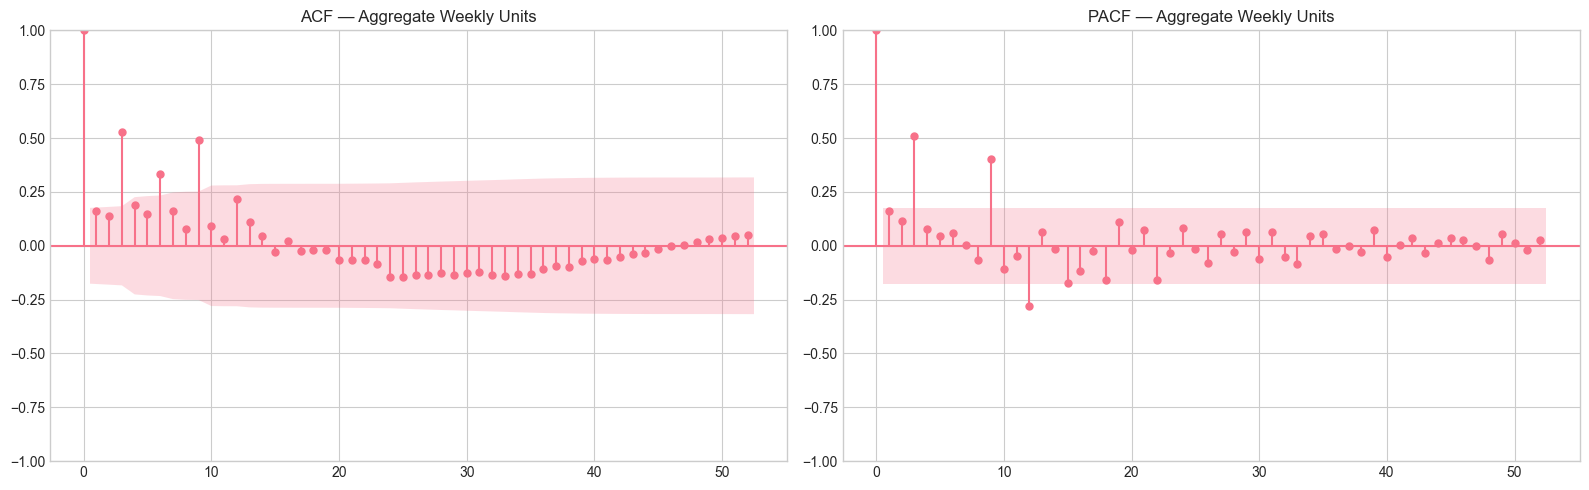

In [32]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Aggregate weekly series
weekly_total = weekly.groupby('week_ending')['units'].sum().sort_index()

# ADF Test
adf_result = adfuller(weekly_total.dropna(), autolag='AIC')
print("=== Augmented Dickey-Fuller Test ===")
print(f"  Test statistic: {adf_result[0]:.4f}")
print(f"  p-value:        {adf_result[1]:.4f}")
print(f"  Lags used:      {adf_result[2]}")
print(f"  Conclusion:     {'Stationary' if adf_result[1] < 0.05 else 'Non-stationary'} (\u03b1=0.05)")

# KPSS Test
kpss_result = kpss(weekly_total.dropna(), regression='ct', nlags='auto')
print(f"\n=== KPSS Test (trend) ===")
print(f"  Test statistic: {kpss_result[0]:.4f}")
print(f"  p-value:        {kpss_result[1]:.4f}")
print(f"  Conclusion:     {'Stationary' if kpss_result[1] > 0.05 else 'Non-stationary'} (\u03b1=0.05)")

# STL Decomposition
n_weeks = len(weekly_total)
stl_period = min(52, n_weeks // 2)  # Use 52 if enough data, else half the series
if n_weeks >= stl_period * 2:
    stl = STL(weekly_total, period=stl_period, robust=True)
    result = stl.fit()
    fig = result.plot()
    fig.set_size_inches(14, 10)
    fig.suptitle(f'STL Decomposition (period={stl_period} weeks)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES / 'stl_decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"\n\u26a0\ufe0f Not enough data for STL decomposition (need {stl_period*2} weeks, have {n_weeks})")

# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
max_lags = min(52, n_weeks // 2 - 1)
plot_acf(weekly_total.dropna(), lags=max_lags, ax=axes[0], title='ACF \u2014 Aggregate Weekly Units')
plot_pacf(weekly_total.dropna(), lags=max_lags, ax=axes[1], title='PACF \u2014 Aggregate Weekly Units', method='ywm')
plt.tight_layout()
plt.savefig(FIGURES / 'acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation of Statistical Tests

**Stationarity (ADF + KPSS)**:
- The **ADF test** checks if the series has a unit root (i.e., is non-stationary / drifts without mean-reverting). A low p-value (< 0.05) rejects the unit root and means the series is stationary.
- The **KPSS test** checks the opposite: the null hypothesis is that the series IS stationary. A high p-value (> 0.05) confirms stationarity.
- If both agree the series is stationary: no differencing is needed before modeling. Prophet and XGBoost can work with the raw series. If non-stationary, differencing or detrending would be required.

**STL Decomposition**:
- Breaks the weekly demand into three components: **Trend** (long-term direction), **Seasonal** (repeating annual cycle), and **Residual** (noise/unexplained variation).
- A strong seasonal component relative to the residual confirms that seasonality is the dominant signal — the model MUST capture the annual cycle to be useful.
- Residual spikes may correspond to promotions, weather events, or one-time occurrences worth investigating.

**ACF / PACF (Autocorrelation)**:
- **ACF** shows how correlated current demand is with demand at each past lag (1 week ago, 2 weeks ago, etc.). Slow decay indicates seasonality or trend.
- **PACF** shows the direct correlation at each lag after removing intermediate effects. Significant spikes indicate which specific lags carry predictive power.
- A significant lag at 1 means last week's demand predicts this week's (autoregressive behavior). A significant lag at ~52 confirms the annual seasonal cycle.
- **For the forecasting model**: Prophet handles trend and seasonality internally. For XGBoost/regression models, the most important lag features are those with significant PACF spikes (typically lag 1 and lag 52).

---
## Year-over-Year Seasonality Overlay (Fiscal Year)

Fiscal year runs Nov 1 - Oct 31. Each line represents one fiscal year so the
seasonal ramp-up (spring) through peak (summer) through wind-down (fall) is
visible as a continuous arc.
---

In [ ]:
weekly_total_df = weekly.groupby('week_ending').agg(
    units=('units','sum'),
    fiscal_year=('fiscal_year','first'),
    fiscal_week=('fiscal_week','first')
).reset_index()

fiscal_years = sorted(weekly_total_df['fiscal_year'].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# All stores overlay by fiscal year
for fy in fiscal_years:
    fy_data = weekly_total_df[weekly_total_df['fiscal_year'] == fy].sort_values('fiscal_week')
    axes[0].plot(fy_data['fiscal_week'], fy_data['units'], label=f'FY{int(fy)}', linewidth=1.5)
axes[0].set_title('Year-over-Year Weekly Units (Fiscal Year)')
axes[0].set_xlabel('Fiscal Week (1 = first week of Nov, from Table Calendrier)')
axes[0].set_ylabel('Total Units')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))

# Top 5 divisions overlay — average across fiscal years by fiscal week
top5_divs = weekly.groupby('division_code')['units'].sum().nlargest(5).index
div_weekly = weekly[weekly['division_code'].isin(top5_divs)].copy()
div_agg = div_weekly.groupby(['division_code', 'fiscal_week'])['units'].mean().reset_index()

for div in top5_divs:
    d = div_agg[div_agg['division_code'] == div]
    axes[1].plot(d['fiscal_week'], d['units'], label=div, linewidth=1.5)
axes[1].set_title('Avg Weekly Units by Division (Top 5)')
axes[1].set_xlabel('Fiscal Week (1 = first week of Nov)')
axes[1].set_ylabel('Avg Units')
axes[1].legend()

plt.suptitle('Seasonal Patterns (Fiscal Year: Nov-Oct)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'yoy_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Panel Structure & Sparsity Analysis

The dataset is a panel: Store \u00d7 Division \u00d7 Week. Understanding which groups
have sufficient data is critical for model selection.

---

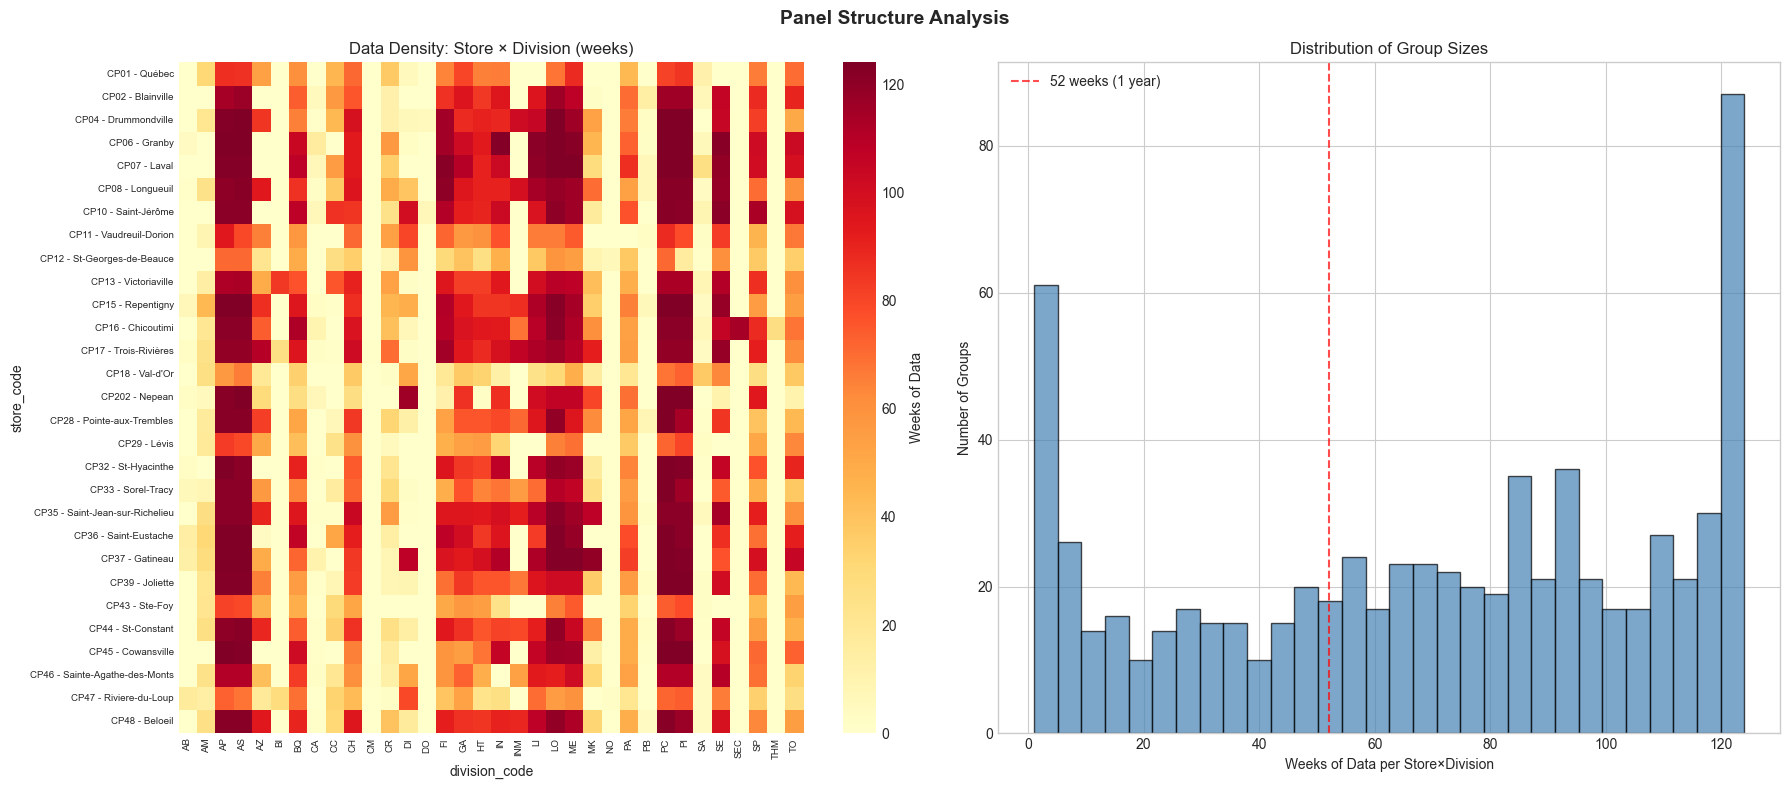

Total groups (Store × Division): 711
Groups with ≥ 52 weeks: 476 (66.9%)
Groups with 26-51 weeks: 94
Groups with < 26 weeks: 141 (19.8%)
Groups with < 10 weeks: 87 (12.2%)

Panel sparsity: 44.3% (fraction of empty cells)


In [ ]:
panel = (
    weekly.groupby(['store_code', 'division_code'])['week_ending']
    .nunique()
    .reset_index(name='n_weeks')
)

# Pivot for heatmap
pivot = panel.pivot_table(index='store_code', columns='division_code', values='n_weeks', fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap
sns.heatmap(pivot, cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Weeks of Data'},
            xticklabels=True, yticklabels=True)
axes[0].set_title('Data Density: Store \u00d7 Division (weeks)')
axes[0].tick_params(axis='both', labelsize=7)

# Histogram of group sizes
axes[1].hist(panel['n_weeks'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=52, color='red', linestyle='--', alpha=0.7, label='52 weeks (1 year)')
axes[1].set_title('Distribution of Group Sizes')
axes[1].set_xlabel('Weeks of Data per Store\u00d7Division')
axes[1].set_ylabel('Number of Groups')
axes[1].legend()

plt.suptitle('Panel Structure Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'panel_structure.png', dpi=150, bbox_inches='tight')
plt.show()

total_groups = len(panel)
print(f"Total groups (Store \u00d7 Division): {total_groups}")
print(f"Groups with \u2265 52 weeks: {(panel['n_weeks'] >= 52).sum()} ({(panel['n_weeks'] >= 52).mean()*100:.1f}%)")
print(f"Groups with 26-51 weeks: {((panel['n_weeks'] >= 26) & (panel['n_weeks'] < 52)).sum()}")
print(f"Groups with < 26 weeks: {(panel['n_weeks'] < 26).sum()} ({(panel['n_weeks'] < 26).mean()*100:.1f}%)")
print(f"Groups with < 10 weeks: {(panel['n_weeks'] < 10).sum()} ({(panel['n_weeks'] < 10).mean()*100:.1f}%)")
max_possible_weeks = weekly['week_ending'].nunique()
sparsity = 1 - (panel['n_weeks'].sum() / (total_groups * max_possible_weeks))
print(f"\nPanel sparsity: {sparsity*100:.1f}% (fraction of empty cells)")

### Panel Sparsity: Modeling Recommendations

Not every store carries every product division, so the store x division panel is inherently sparse.
For downstream forecasting, we recommend tiered handling based on data availability:

| Group Size | Recommendation |
|-----------|---------------|
| **>= 52 weeks** | Full forecasting model with annual seasonality |
| **26-51 weeks** | Simplified model — no year-over-year regressors, shorter lag features |
| **10-25 weeks** | Pool with division-level or store-level aggregates to borrow strength |
| **< 10 weeks** | Exclude from individual forecasting — use division median from other stores |

**Action item for client**: Some division codes appear in very few stores or weeks.
Are these real product lines, or data artifacts (e.g., one-time transfers, internal codes)?
Confirming which divisions are active product lines would help us focus the model.

---
## Data Quality Summary & Next Steps

| Dimension | Status | Detail |
|-----------|--------|--------|
| **Completeness** | Partial | ~32 of ~39 retail stores have slice data. Missing: CP03, CP21, CP23, CP31, CP41, CP49, CP50 |
| **Returns** | Handled | Negative-quantity rows netted at weekly level, clipped to 0 |
| **Zero-unit weeks** | Present | Expected for niche divisions in off-season |
| **Store exclusions** | Data-driven | Liquidation and test stores removed automatically; see diagnostic table above |
| **Fiscal year** | Aligned | From Table Calendrier (client's official fiscal calendar) |
| **Store metadata** | Enriched | City, franchise group, POS system from Table_Magasins |
| **Division codes** | Unknown | 34 internal ERP codes — meanings not in data |

### Available Raw Data Files

| File | Used? | Contents |
|------|-------|----------|
| `slices/*.xlsx` (32 files) | Yes | Transaction-level unit data per store |
| `Table Calendrier.xlsx` | Yes | Official fiscal calendar (fiscal year, week, quarter) |
| `Table_Magasins.xlsx` | Yes | Store master (city, franchise group, POS system) |
| `Exemple_Table_Vente.xlsx` | Not yet | Full sales table with revenue (`Montant de la ligne`), unit price, discounts |
| `Exemple Table ITEM TOTAL.xlsx` | Not yet | Item/product master (SKU details, division mapping) |
| `Exemple_Table_Inventaire.xlsx` | Not yet | Inventory by item/store/date (quantity, available, reserved, unit cost, value) |

### Units vs Revenue: What Are We Forecasting?

The slice exports contain **units only** (`Quantite facturee`). However, `Exemple_Table_Vente.xlsx`
has revenue data (`Montant de la ligne`, `Prix de vente unitaire`, `Escompte en %`).

**Decision needed**: Should we forecast **units**, **revenue ($)**, or **both**?
- Units are more stable for inventory planning (not affected by pricing changes)
- Revenue is more relevant for financial forecasting and budget allocation
- If revenue is needed, the slice exports must be re-done with the revenue column

### Inventory Data: Do We Need It?

`Exemple_Table_Inventaire.xlsx` has current inventory levels (quantity, available, reserved) and
unit cost per item/store. This could be useful for:
- Comparing forecasted demand vs current stock (gap analysis)
- Identifying stockout risk by store/division
- Inventory value forecasting

### Action Items for Client

1. **Division code mapping**: 34 division codes need human-readable names
2. **Missing stores**: 7 retail stores from Table_Magasins have no slice data (CP03-Brossard, CP21-Rimouski, CP23-Terrebonne, CP31-Pierrefonds, CP41-St-Hubert, CP49-Bonaventure, CP50-Rouyn-Noranda). Are slice exports available for these?
3. **Units vs revenue**: Do we need revenue forecasting? If so, add `Montant de la ligne` to slice exports.
4. **Inventory integration**: Should inventory levels be factored into the forecasting model?
5. **Uneven data coverage**: Some stores have fewer weeks than others — confirm if any stores opened/closed during the period.

### Next Steps in Pipeline

- **NB02 — Weather Integration**: Merge city-level weather data onto weekly units
- **NB03 — Feature Engineering**: Seasonality (Fourier), lags, weather interactions, holiday flags
- **NB04 — Forecasting Model**: Prophet / XGBoost per store x division group